# Exploratory Data Analysis for place_data.csv

This notebook loads the place dataset with pandas, checks data quality, and explores the most common vibe tags and place types.

In [2]:
import ast
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

csv_path = Path('place_data.csv')
df = pd.read_csv(csv_path)
original_columns = df.columns.tolist()

def parse_braced_list(value):
    if pd.isna(value):
        return []

    text = str(value).strip()
    if not text:
        return []

    if text.startswith('{') and text.endswith('}'):
        candidate = text.replace('{', '[').replace('}', ']')
        try:
            parsed = ast.literal_eval(candidate)
            if isinstance(parsed, list):
                return [str(item).strip() for item in parsed]
        except Exception:
            pass
        return [item.strip().strip('"') for item in text[1:-1].split(',') if item.strip()]

    return [text]

for col in ['latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['vibe_list'] = df['vibeTags'].apply(parse_braced_list)
df['type_list'] = df['types'].apply(parse_braced_list)
df['description_length'] = df['description'].fillna('').str.len()

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())
print('\nMissing values by column:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_values'))
print(f'Duplicate rows: {df[original_columns].duplicated().sum()}')
print('\nNumeric summary:')
display(df[['latitude', 'longitude', 'description_length']].describe().T)

Dataset shape: 334 rows x 11 columns


,id,name,description,vibeTags,types,latitude,longitude,activityHours,vibe_list,type_list,description_length
0,ChIJK3qPbb0rdTERuqIfQ0MtaRU,HanFood - Lẩu Nướng Hàn Quốc,Quán đồ nướng học sinh sinh vien ngay sau lưng...,"{Chill,Bustling,Outdoor,Minimalist,Aesthetic,""...","{restaurant,food,point_of_interest,establishme...",10.867804,106.613919,"[""Monday: 4:00 – 10:00 PM"",""Tuesday: 4:00 – 10...","[Chill, Bustling, Outdoor, Minimalist, Aesthet...","[restaurant, food, point_of_interest, establis...",212
1,63a27a0b-ca82-4815-83ab-6a7181fbade5,M Village Living 59 Thảo Điền,Là serviced apartment mang phong cách tối giản...,"{Cozy,Romantic,Chill,Aesthetic,Vintage,Outdoor...",{Lounge},10.808810,106.731090,Open 24/7,"[Cozy, Romantic, Chill, Aesthetic, Vintage, Ou...",[Lounge],617
2,ChIJQ_AEI9YvdTERhEqq0pB7nfs,Ngõ Thái - Quận 10,Quán ăn món Thái phù hợp ăn trưa và ăn tối ở q...,"{Loud,Chill,Outdoor,""Family Friendly"",""Pet Fri...","{bistro,restaurant,food,point_of_interest,esta...",10.776049,106.665060,"[""Monday: 4:00 – 10:00 PM"",""Tuesday: 4:00 – 10...","[Loud, Chill, Outdoor, Family Friendly, Pet Fr...","[bistro, restaurant, food, point_of_interest, ...",210
3,056d492c-fa62-438c-9ef5-0c9ef21b7993,ThisThat Bakery Cafe,Quán cafe siêu rộng với các góc chụp ảnh phong...,"{Cozy,Romantic,Chill,Quiet,Aesthetic,Vintage,O...","{Restaurant,Cafe,""Dessert Shop"",Bakery}",10.808350,106.739020,8:00 - 21:30,"[Cozy, Romantic, Chill, Quiet, Aesthetic, Vint...","[Restaurant, Cafe, Dessert Shop, Bakery]",143
4,914a7ce9-41d3-498e-83b2-80e712332985,Chị Mơ,Chị Mơ là quán ăn Việt mang phong cách mộc mạc...,"{Cozy,Chill,Vintage,Aesthetic,Outdoor,""Family ...",{Restaurant},10.805420,106.732950,07:00 - 22:00,"[Cozy, Chill, Vintage, Aesthetic, Outdoor, Fam...",[Restaurant],585



Missing values by column:


,missing_values
activityHours,9
name,1
id,0
description,0
vibeTags,0
latitude,0
types,0
longitude,0
vibe_list,0
type_list,0


Duplicate rows: 0

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
latitude,334.0,13.238695,4.327145,10.73581,10.803400,10.838518,10.907949,2.100826e+01
longitude,334.0,32071.740942,584186.316195,105.72567,106.598341,106.681398,106.738088,1.067650e+07
description_length,334.0,297.185629,130.058620,65.00000,191.250000,285.000000,394.500000,6.320000e+02


Top vibe tags:


,count
Family Friendly,215
Chill,171
Cozy,149
Aesthetic,114
Vintage,102
Loud,99
Outdoor,98
Modern,75
Romantic,73
Quiet,58



Top place types:


,count
Restaurant,169
establishment,145
point_of_interest,145
food,133
Cafe,132
restaurant,84
cafe,45
store,43
Fine Dining,41
Bakery,41


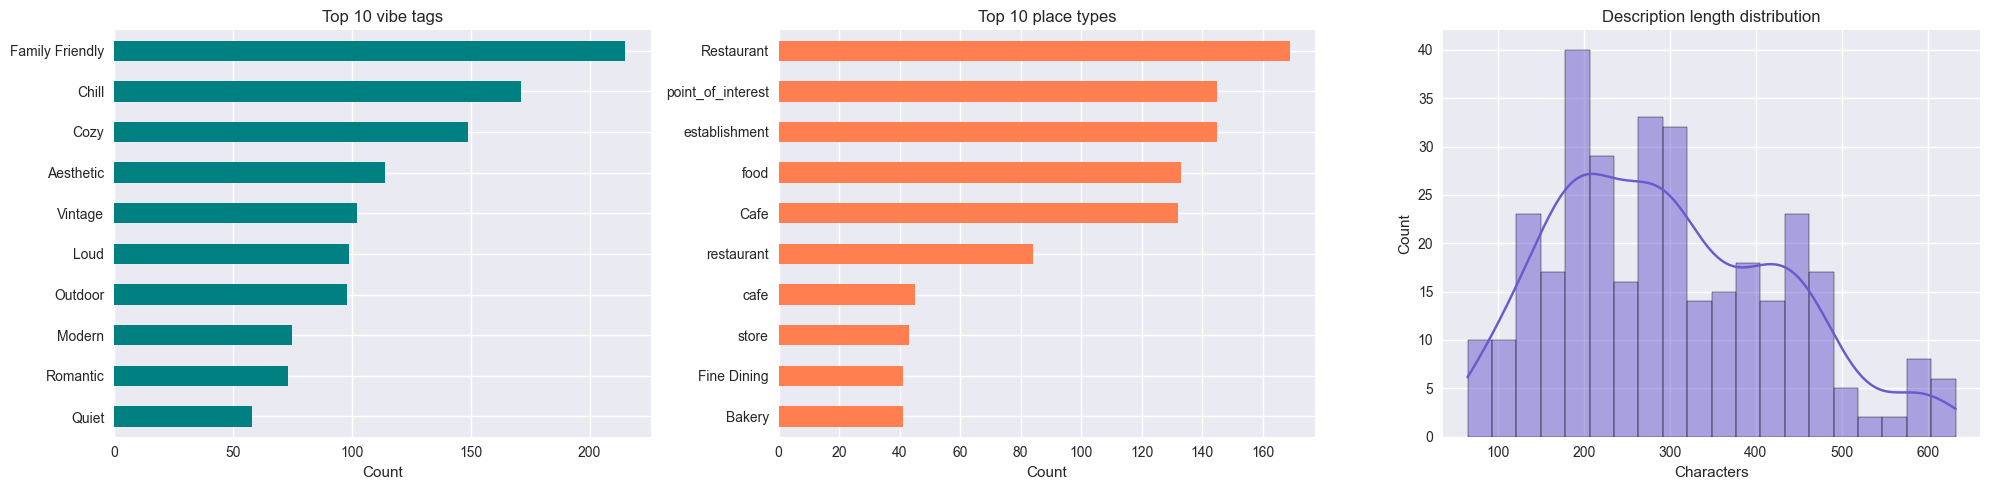

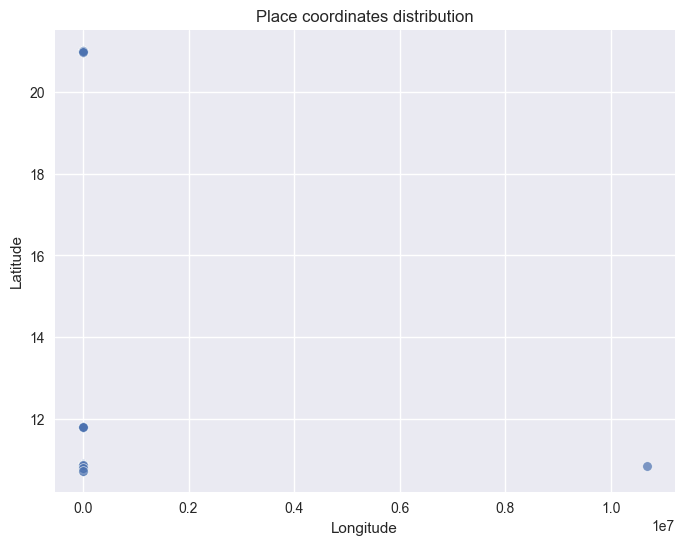

In [3]:
vibe_counts = pd.Series(Counter(tag for tags in df['vibe_list'] for tag in tags)).sort_values(ascending=False)
type_counts = pd.Series(Counter(tag for types in df['type_list'] for tag in types)).sort_values(ascending=False)

print('Top vibe tags:')
display(vibe_counts.head(10).rename('count').to_frame())
print('\nTop place types:')
display(type_counts.head(10).rename('count').to_frame())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

vibe_counts.head(10).sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 10 vibe tags')
axes[0].set_xlabel('Count')

type_counts.head(10).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 place types')
axes[1].set_xlabel('Count')

sns.histplot(df['description_length'], bins=20, kde=True, ax=axes[2], color='slateblue')
axes[2].set_title('Description length distribution')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', alpha=0.7)
plt.title('Place coordinates distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()